<a href="https://colab.research.google.com/github/youssef-bendhaou/COMPUTER-VISION/blob/main/smoking%20detector/smoking_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cvzone mediapipe opencv-python -q

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.1 MB/s eta 0:00:00
Mounted at /content/drive


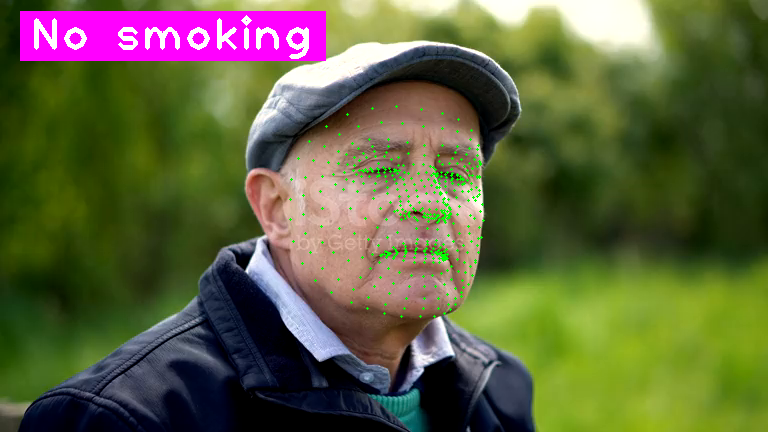

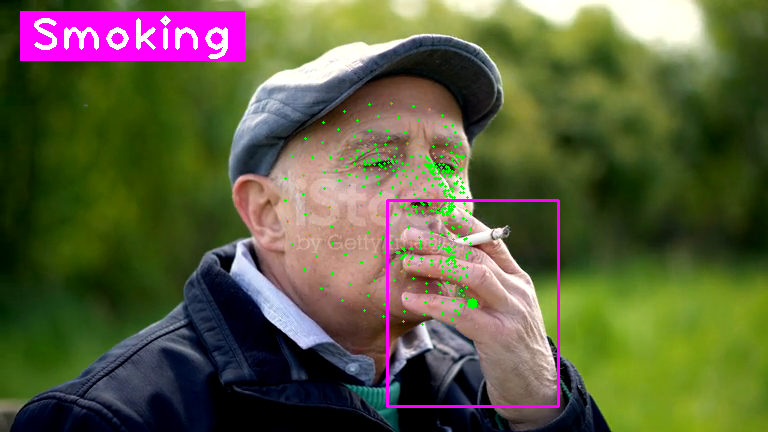

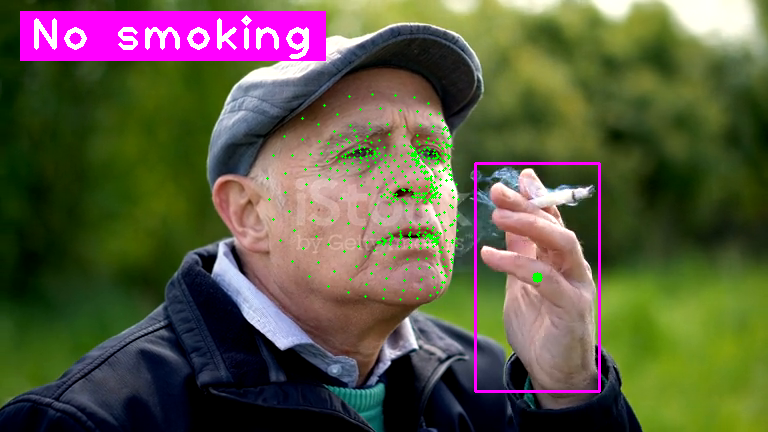

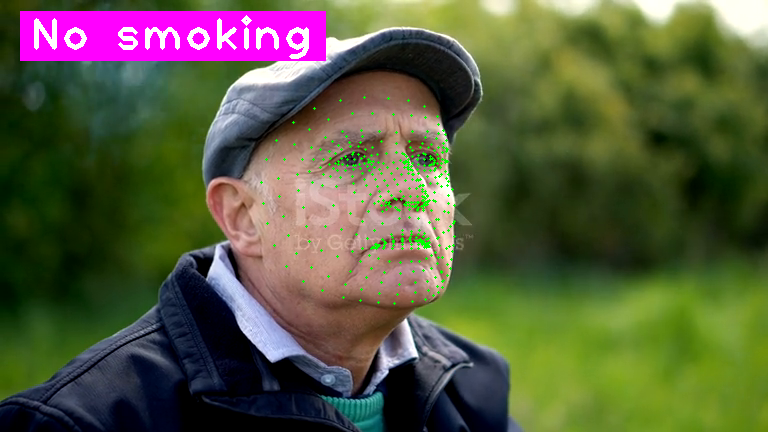

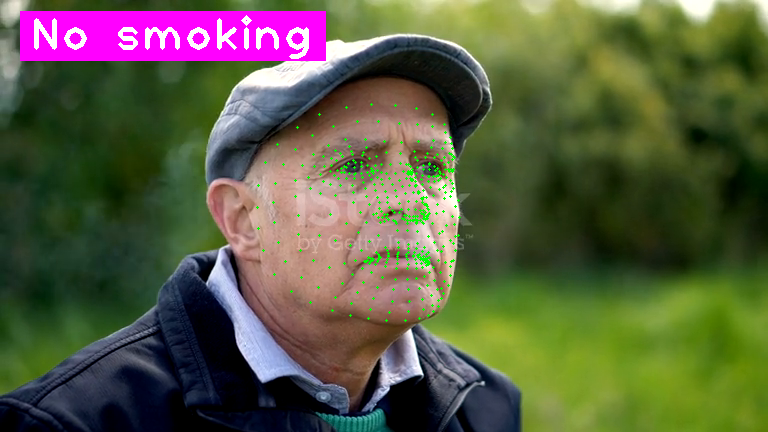

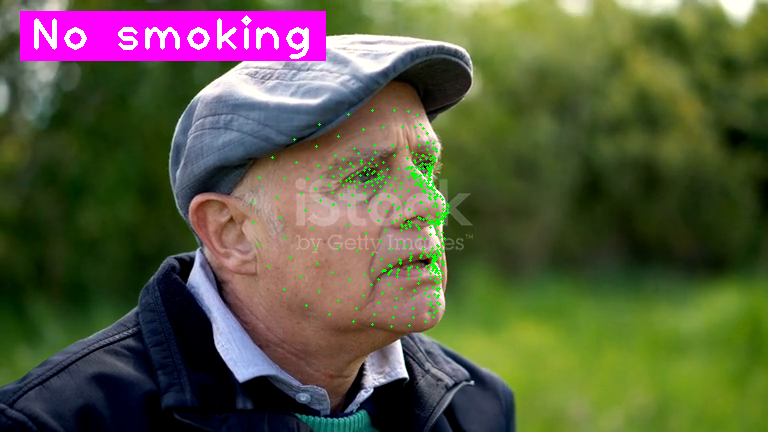

Terminé. Vidéo sauvegardée dans : /content/drive/MyDrive/computer vision/smoking detector/smoking_output.mp4


In [6]:
import cv2
import cvzone
from cvzone.FaceMeshModule import FaceMeshDetector
from cvzone.HandTrackingModule import HandDetector
from google.colab.patches import cv2_imshow

# --- Chemins (à adapter) ---
input_path  = '/content/drive/MyDrive/computer vision/smoking detector/smoking.mp4'
output_path = '/content/drive/MyDrive/computer vision/smoking detector/smoking_output.mp4'

Hand_Detector = HandDetector()
MeshDetector = FaceMeshDetector()

video = cv2.VideoCapture(input_path)
if not video.isOpened():
    raise FileNotFoundError(f"Impossible d'ouvrir la vidéo : {input_path}")

# Paramètres de la vidéo pour l'écriture
fps = video.get(cv2.CAP_PROP_FPS) or 25
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

point11X = point11Y = 0
frame_count = 0

while True:
    ret, image = video.read()
    if not ret:          # fin de la vidéo
        break

    img, faces = MeshDetector.findFaceMesh(image, draw=True)
    results = Hand_Detector.findHands(image, draw=True)

    if len(results[0]) > 0:
        landmarks = results[0][0]['lmList']
        point11X, point11Y = landmarks[11][0], landmarks[11][1]

    # On vérifie qu'un visage a été détecté (sinon faces[0] plante)
    if len(faces) > 0:
        point14 = faces[0][14]  # point de la lèvre
        distance = MeshDetector.findDistance((point11X, point11Y),
                                             (point14[0], point14[1]))[0]
        if distance < 40:
            cvzone.putTextRect(image, 'Smoking', (30, 50))
        else:
            cvzone.putTextRect(image, 'No smoking', (30, 50))

    writer.write(image)

    # Afficher une image toutes les 30 frames (pour ne pas surcharger Colab)
    if frame_count % 30 == 0:
        cv2_imshow(image)
    frame_count += 1

video.release()
writer.release()
print("Terminé. Vidéo sauvegardée dans :", output_path)